# 01. Data Analysis

## 1. Introduction
This notebook performs primary exploratory analysis on the PaySim dataset, a synthetic mobile money transaction dataset designed for fraud detection research. The aim of this notebook is to:

- Understand the structure and characteristics of the dataset
- Investigate patterns associated with fraudulent transactions
- Test several feature engineering hypotheses
- Select a set of useful features for the fraud detection model

The analysis focuses on identifying behavioral signals of fraud, rather than relying only on raw transaction attributes. The selected features from this notebook will be used in the next stage of model training.

In [ ]:
# Project path setup 
import os
from pathlib import Path

# Find project root (the folder containing ml_pipeline)
current = Path.cwd()

while not (current / "ml_pipeline").exists():
    current = current.parent

PROJECT_ROOT = current

print("Project root:", PROJECT_ROOT)

# Data path
DATA_PATH = PROJECT_ROOT / "ml_pipeline" / "data" / "onlinefraud.csv"

print("Dataset path:", DATA_PATH)
print("File exists:", DATA_PATH.exists())

Project root: e:\AnomalyWatchers-DonutPuff
Dataset path: e:\AnomalyWatchers-DonutPuff\ml_pipeline\data\onlinefraud.csv
File exists: True


## 2. Data Loading and Initial Inspection
In this section, the dataset is loaded and its basic structure is checked. This helps confirm that the data has been imported correctly and provides an initial view of the available variables.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(DATA_PATH)


# Basic inspection
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (6362620, 11)

Columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 3. Dataset Overview

Before testing fraud hypotheses, it is useful to understand the overall structure of the dataset. This section examines:
- The distribution of fraudulent transactions
- The distribution of transaction types
- Whether the dataset contains missing values
- Understanding these characteristics helps provide context for the later analysis.

In [72]:
# Fraud distribution
fraud_counts = df["isFraud"].value_counts()

# Fraud rate
fraud_rate = df["isFraud"].mean() * 100

print("Fraud distribution:")
print(f"Non-fraud transactions : {fraud_counts[0]:,}")
print(f"Fraud transactions     : {fraud_counts[1]:,}")

print("\nFraud rate:")
print(f"{fraud_rate:.2f}%")

Fraud distribution:
Non-fraud transactions : 6,354,407
Fraud transactions     : 8,213

Fraud rate:
0.13%


#### **Insight:** 
- Fraud cases are very rare
- This indicates class imbalance, which is typical in fraud detection.

In [74]:
# Transaction type summary
type_counts = (
    df["type"]
    .value_counts()
    .rename_axis("transaction_type")
    .reset_index(name="count")
)

type_counts["percent"] = (type_counts["count"] / len(df) * 100).round(2)

print("Transaction type distribution:\n")
print(type_counts.to_string(index=False))

# Missing values summary

missing_summary = (
    df.isnull()
    .sum()
    .rename("missing_count")
    .reset_index()
    .rename(columns={"index": "column"})
)

missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(df) * 100
).round(2)

print("\nMissing values per column:\n")
print(missing_summary.to_string(index=False))

Transaction type distribution:

transaction_type   count  percent
        CASH_OUT 2237500   35.170
         PAYMENT 2151495   33.810
         CASH_IN 1399284   21.990
        TRANSFER  532909    8.380
           DEBIT   41432    0.650

Missing values per column:

          column  missing_count  missing_percent
            step              0            0.000
            type              0            0.000
          amount              0            0.000
        nameOrig              0            0.000
   oldbalanceOrg              0            0.000
  newbalanceOrig              0            0.000
        nameDest              0            0.000
  oldbalanceDest              0            0.000
  newbalanceDest              0            0.000
         isFraud              0            0.000
  isFlaggedFraud              0            0.000
 errorBalanceOrg              0            0.000
errorBalanceDest              0            0.000
    amount_ratio              0            0.000


#### **Insights:**
- Multiple transaction types exist (TRANSFER, CASH_OUT, etc.)
- The dataset contains no missing values

## 4. Correlation Analysis of Balance Features

To explore relationships between transaction balances and fraud, several balance-related variables are examined. Two additional variables are created to represent potential discrepancies between transaction amounts and account balances:
- errorBalanceOrg — difference between expected and recorded sender balance
- errorBalanceDest — difference between expected and recorded destination balance.

These features are sometimes used in fraud detection research to identify suspicious balance inconsistencies.

In [58]:
# Create balance error features
df["errorBalanceOrg"] = df["oldbalanceOrg"] - df["newbalanceOrig"] - df["amount"]
df["errorBalanceDest"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]

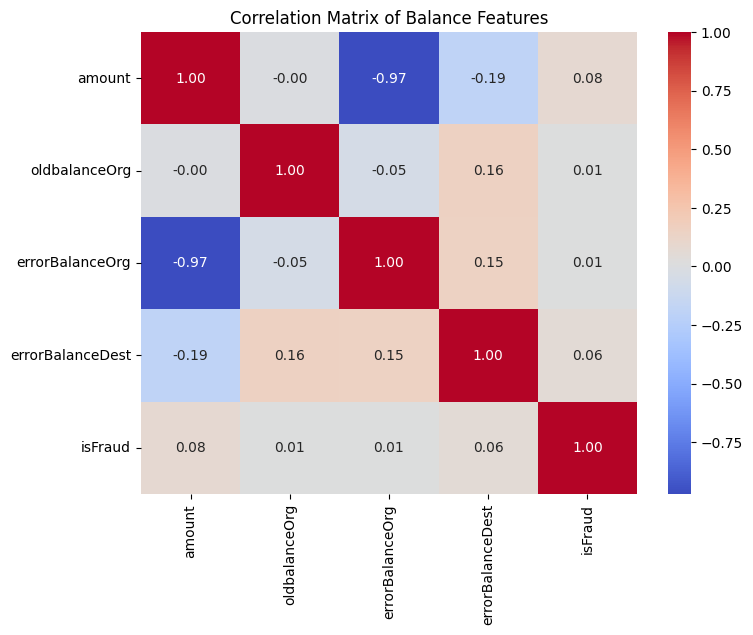

In [59]:
# Correlation analysis
corr_cols = [
    "amount",
    "oldbalanceOrg",
    "errorBalanceOrg",
    "errorBalanceDest",
    "isFraud"
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Balance Features")
plt.show()

#### **Interpretation**
- oldbalanceOrg shows almost no correlation with fraudulent transactions (≈ 0.01), indicating that the sender’s initial balance alone is not strongly related to whether a transaction is fraudulent.

- errorBalanceOrg and errorBalanceDest have very weak correlations with the fraud label, suggesting that balance inconsistencies do not show a strong linear relationship with fraud when considered individually.

- errorBalanceOrg is extremely strongly negatively correlated with transaction amount (≈ −0.97). This is expected because the feature is mathematically derived from balance and transaction values.

Overall, most variables exhibit weak direct correlations with fraud, implying that fraudulent behavior in this dataset is likely influenced by more complex interactions between features rather than simple linear relationships.

Based on these observations, the balance error features do not appear to provide meaningful predictive information and are therefore not considered further in the feature engineering process.

## 5. Hypothesis 1 — Fraud Drains the Sender Account

Fraudulent transactions may attempt to transfer a large proportion of the sender's available balance in a single transaction. To examine this behavior, a new feature is created:

amount_ratio = amount / oldbalanceOrg

This ratio measures the size of the transaction relative to the sender's account balance. If fraudsters attempt to empty the account, the ratio should be close to 1.

In [70]:
# Create ratio feature
df["amount_ratio"] = df["amount"] / (df["oldbalanceOrg"] + 1)

# Compute summary statistics
ratio_stats = df.groupby("isFraud")["amount_ratio"].describe()

# Round values for readability
ratio_stats = ratio_stats.round(3)

# Display
pd.options.display.float_format = "{:,.3f}".format
ratio_stats


,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,"6,354,407.000","70,764.321","508,745.259",0.000,0.233,6.512,"12,355.590","92,445,516.640"
1,"8,213.000","1,161.967","32,297.153",0.000,1.000,1.000,1.000,"1,933,920.800"


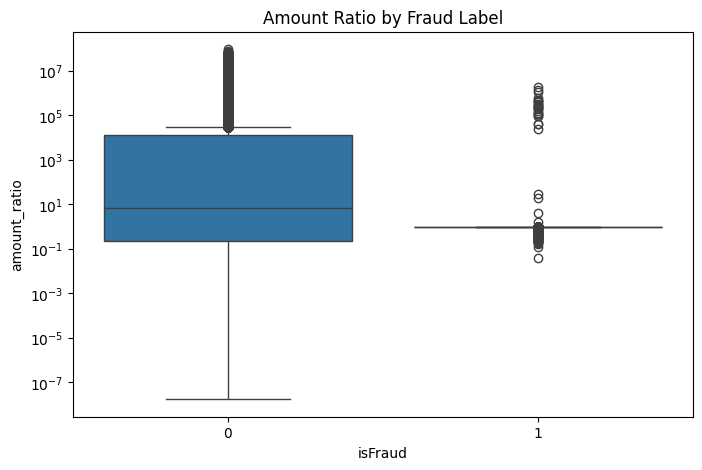

In [75]:
# Visual comparison
plt.figure(figsize=(8,5))
sns.boxplot(x="isFraud", y="amount_ratio", data=df)
plt.yscale("log")
plt.title("Amount Ratio by Fraud Label")
plt.show()

#### **Interpretation**
Fraudulent transactions show amount_ratio values extremely close to 1, indicating that attackers often attempt to transfer nearly the entire available balance from the sender’s account in a single transaction. 

In contrast, legitimate transactions display a much wider distribution of amount_ratio values, reflecting more varied spending behavior. 

This clear separation suggests that the relative transaction size compared to the sender’s balance is a useful behavioral indicator of fraud, even though some legitimate transactions may also produce large ratios due to balance inconsistencies or data characteristics.

## 6. Hypothesis 2 — Transfers to Empty Destination Accounts

Another possible indicator of fraud is the state of the destination account before the transaction.

Fraudulent transfers may target new or previously unused accounts, often referred to as mule accounts. These accounts may have no prior balance before receiving the fraudulent transfer.

To test this idea, a binary feature is created:

dest_is_empty = oldbalanceDest == 0

This variable indicates whether the destination account had a zero balance before the transaction.

In [65]:
# Create indicator for empty destination accounts
df["dest_is_empty"] = (df["oldbalanceDest"] == 0).astype(int)

# Compare fraud rates
result = df.groupby("dest_is_empty")["isFraud"].agg(["count", "sum", "mean"])

# Convert fraud rate to percentage
result["fraud_rate_%"] = (result["mean"] * 100).round(3)

result

,count,sum,mean,fraud_rate_%
dest_is_empty,,,,
0,3658232,2862,0.000782,0.078
1,2704388,5351,0.001979,0.198


#### **Interpretation**

• Transactions sent to destination accounts with zero prior balance show a higher fraud rate (≈0.198%) compared to transactions sent to accounts with existing balances (≈0.078%).

• This suggests that fraudulent transfers are more likely to involve accounts that previously held no funds, which may represent newly created or inactive accounts used as temporary mule accounts.

• Although the absolute fraud probability remains low, the dest_is_empty feature captures a meaningful behavioral pattern and may serve as a useful signal when combined with other fraud indicators.

## 7. Hypothesis 3 — Transfer to Empty Destination Accounts

The previous section showed that fraudulent transactions often involve destination accounts with zero prior balance. However, this signal may depend on the type of transaction. Fraudulent activity may specifically involve transfers into empty accounts, rather than other transaction types.

To capture this behavior, an interaction feature is created:

transfer_to_empty =
(type == "TRANSFER") AND (oldbalanceDest == 0)

This feature identifies transactions where funds are transferred into a destination account that previously had no balance.

In [76]:
# Interaction feature: transfer to empty destination account
df["transfer_to_empty"] = (
    (df["type"] == "TRANSFER") &
    (df["oldbalanceDest"] == 0)
).astype(int)

# Compare fraud rates
df.groupby("transfer_to_empty")["isFraud"].agg(["count", "sum", "mean"])

,count,sum,mean
transfer_to_empty,,,
0,6297487,4121,0.001
1,65133,4092,0.063


#### **Interpretation**

- Transactions classified as **transfer_to_empty** (TRANSFER to an account with zero prior balance) show a much higher fraud rate than other transactions.

- While most transactions have a fraud rate of about 0.1%, transfers into empty destination accounts show a fraud rate of approximately 6.3%.

- This means fraud is over 60 times more likely in transactions that match this pattern.

- This behavior suggests that fraudsters often transfer stolen funds into newly created or inactive accounts, which may function as temporary mule accounts before the money is withdrawn or moved again.


## 8. Hypothesis 4 — Large Transfers Relative to Destination Balance

Fraudulent transactions may involve transferring amounts that are very large relative to the destination account's prior balance.

To examine this behavior, the following ratio is defined:

amount_to_dest_balance = amount / (oldbalanceDest + 1)

This feature measures how large the incoming transfer is compared to the destination account balance before the transaction.

In [80]:
# Create ratio feature
df["amount_to_dest_balance"] = df["amount"] / (df["oldbalanceDest"] + 1)

# Summary statistics by fraud label
dest_ratio_stats = (
    df.groupby("isFraud")["amount_to_dest_balance"]
    .agg(
        transactions="count",
        mean_ratio="mean",
        median_ratio="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        max_ratio="max"
    )
    .round(3)
)

dest_ratio_stats

,transactions,mean_ratio,median_ratio,q25,q75,max_ratio
isFraud,,,,,,
0,6354407,"26,666.308",0.915,0.160,"9,698.210","60,965,275.640"
1,8213,"969,883.437","116,419.580",4.368,"799,123.570","10,000,000.000"


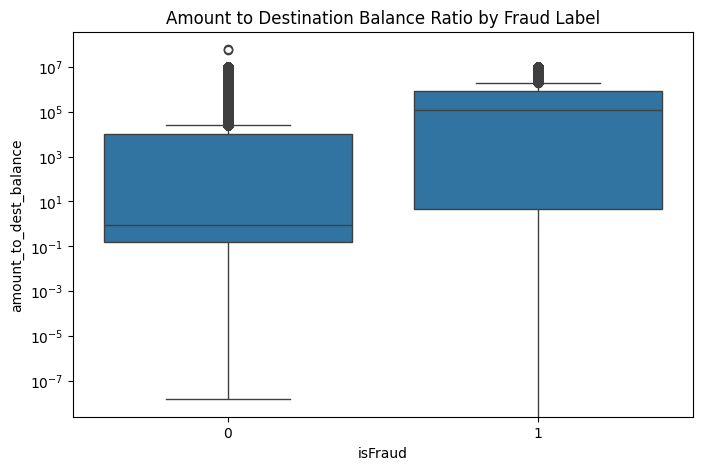

In [81]:
# Visual comparison
plt.figure(figsize=(8,5))
sns.boxplot(x="isFraud", y="amount_to_dest_balance", data=df)
plt.yscale("log")
plt.title("Amount to Destination Balance Ratio by Fraud Label")
plt.show()

#### **Interpretation**

- Fraudulent transactions have much larger **amount_to_dest_balance** ratios than normal transactions.

- The median ratio for normal transactions is 0.915, meaning the transfer amount is typically close to the destination account’s existing balance.

- In contrast, the median ratio for fraudulent transactions is 116,419, indicating that fraud transfers are often orders of magnitude larger than the destination account’s prior balance.

- The 75th percentile for fraud transactions (≈ 799,124) is dramatically higher than that of normal transactions (≈ 9,698), further showing that fraudulent transfers frequently involve extremely large amounts relative to the destination balance.

- This pattern suggests that attackers often transfer funds into accounts that previously held very little money, consistent with the behavior of temporary mule accounts used to receive stolen funds.

- Therefore, the amount_to_dest_balance feature captures a strong behavioral signal and may be useful for identifying suspicious transactions._